In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
deepcsa_run_dir = '/data/bbg/nobackup2/scratch/mhuertas/tests_dupcaller/20260624_bladder_rerun'

In [3]:
# omegas = pd.read_table("../data/bladder/omega.flagged_annotated.tsv")
# omegas = pd.read_table(f"{deepcsa_run_dir}/selection/omegagloballoc/all_omega_globalloc.tsv")
omegas = pd.read_table(f"{deepcsa_run_dir}/selection/omega/omega.flagged_annotated.tsv")
omegas.head()

,gene,sample,impact,mutations,dnds,pvalue,lower,upper,pvalue_adj,flagged,flag_reason
0,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0051_BDO_01_dupcaller,missense,1,0.332614,0.179826,0.019452,1.471530,0.340571,False,NaN
1,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0051_BDO_01_dupcaller,nonsense,4,8.495313,0.001706,2.575170,20.654126,0.007787,False,NaN
2,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0051_BDO_01_dupcaller,truncating,4,8.495313,0.001706,2.575170,20.654126,0.007787,False,NaN
3,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0051_BDO_01_dupcaller,nonsynonymous_splice,5,1.432809,0.450743,0.511596,3.105783,0.581779,False,NaN
4,KMT2D--PHD/RING_ZnF,P19_0051_BDO_01_dupcaller,missense,2,0.861719,0.829799,0.143081,2.684229,0.884412,False,NaN


In [4]:
reduced_omegas_deepumicaller = omegas[(omegas["sample"].isin(['CallerDeepumicaller']))
                        & (omegas["impact"].isin(['missense', 'truncating']))
                        ]
reduced_omegas_dupcaller = omegas[(omegas["sample"].isin(['CallerDupcaller']))
                        & (omegas["impact"].isin(['missense', 'truncating']))
                        ]

reduced_omegas = reduced_omegas_deepumicaller.merge(reduced_omegas_dupcaller, on = ["gene", "impact"], suffixes=('_deepumicaller', '_dupcaller'))
# reduced_omegas = reduced_omegas[~(reduced_omegas["gene"].str.contains("--exon"))]
reduced_omegas = reduced_omegas[~(reduced_omegas["gene"].str.contains("--"))]

reduced_omegas

,gene,sample_deepumicaller,impact,mutations_deepumicaller,dnds_deepumicaller,pvalue_deepumicaller,lower_deepumicaller,upper_deepumicaller,pvalue_adj_deepumicaller,flagged_deepumicaller,flag_reason_deepumicaller,sample_dupcaller,mutations_dupcaller,dnds_dupcaller,pvalue_dupcaller,lower_dupcaller,upper_dupcaller,pvalue_adj_dupcaller,flagged_dupcaller,flag_reason_dupcaller
9,RB1,CallerDeepumicaller,missense,24,0.993945,9.777449e-01,0.640340,1.467578,9.777449e-01,False,NaN,CallerDupcaller,39,0.773437,1.110144e-01,0.549029,1.057861,1.259268e-01,False,NaN
10,RB1,CallerDeepumicaller,truncating,7,1.639063,2.323667e-01,0.698056,3.218652,2.522838e-01,False,NaN,CallerDupcaller,11,1.225098,5.230014e-01,0.629415,2.131470,5.444946e-01,False,NaN
32,TERTpromoter,CallerDeepumicaller,missense,4,58.512500,7.748604e-07,17.808200,141.082690,1.143483e-06,False,NaN,CallerDupcaller,12,27.775000,1.170000e-38,14.348358,49.081152,1.852500e-38,False,NaN
35,KMT2C,CallerDeepumicaller,missense,61,1.457813,8.873820e-03,1.103636,1.891162,1.143068e-02,False,NaN,CallerDupcaller,103,1.276563,2.903044e-02,1.026095,1.572583,3.587502e-02,False,NaN
36,KMT2C,CallerDeepumicaller,truncating,19,3.411720,1.895428e-05,2.035584,5.390479,2.643165e-05,False,NaN,CallerDupcaller,33,2.972656,5.960465e-07,1.998365,4.284302,8.970204e-07,False,NaN
44,FOXQ1,CallerDeepumicaller,missense,49,2.478125,1.192093e-07,1.809875,3.312476,1.848960e-07,True,high_mutdensity - zscore > 2,CallerDupcaller,91,2.143750,1.170000e-38,1.682722,2.699170,1.852500e-38,True,high_mutdensity - zscore > 2
45,FOXQ1,CallerDeepumicaller,truncating,5,2.153122,1.393581e-01,0.749838,4.871628,1.557532e-01,True,high_mutdensity - zscore > 2,CallerDupcaller,9,2.299219,3.410155e-02,1.071893,4.331079,4.146748e-02,True,high_mutdensity - zscore > 2
65,TP53,CallerDeepumicaller,missense,48,4.793750,1.170000e-38,3.513723,6.378223,1.852500e-38,False,NaN,CallerDupcaller,84,3.674988,1.170000e-38,2.895641,4.604553,1.852500e-38,False,NaN
66,TP53,CallerDeepumicaller,truncating,5,3.265625,2.789044e-02,1.161709,7.121826,3.474875e-02,False,NaN,CallerDupcaller,8,2.521875,2.486885e-02,1.140834,4.767358,3.124020e-02,False,NaN
67,CDKN1A,CallerDeepumicaller,missense,9,0.907910,7.706637e-01,0.433526,1.653149,7.809393e-01,False,NaN,CallerDupcaller,37,1.425000,5.067074e-02,0.999395,1.966992,6.064530e-02,False,NaN


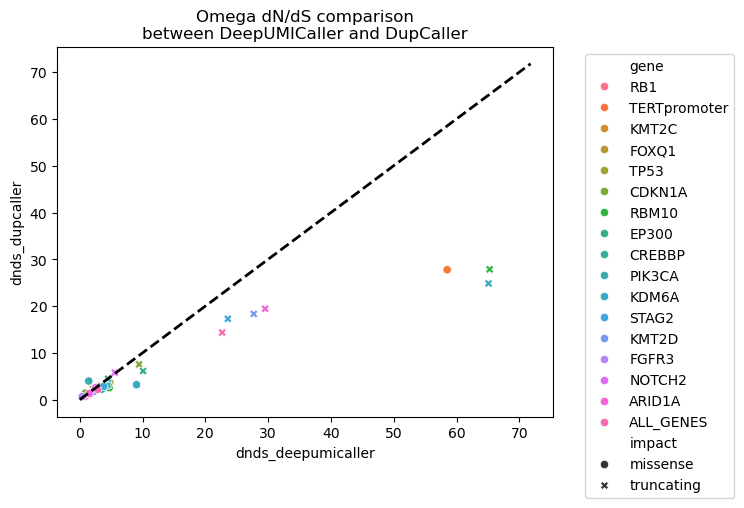

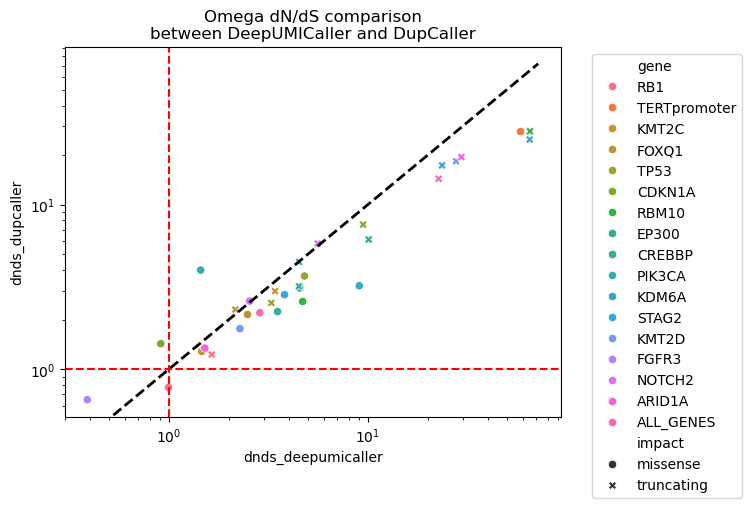

In [5]:
sns.scatterplot(data=reduced_omegas, x="dnds_deepumicaller", y="dnds_dupcaller",
            hue = 'gene',
            style = "impact",
            # kind="box",
            # height=4, aspect=1.5
            )
max_dnds = max(reduced_omegas["dnds_deepumicaller"].max(), reduced_omegas["dnds_dupcaller"].max()) * 1.1

# add x = y line
plt.plot([0, max_dnds], [0, max_dnds], 'k--', lw=2)
# plt.xscale('log')
# plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Omega dN/dS comparison\nbetween DeepUMICaller and DupCaller")
plt.show()



sns.scatterplot(data=reduced_omegas, x="dnds_deepumicaller", y="dnds_dupcaller",
            hue = 'gene',
            style = "impact",
            # kind="box",
            # height=4, aspect=1.5
            )
max_dnds = max(reduced_omegas["dnds_deepumicaller"].max(), reduced_omegas["dnds_dupcaller"].max()) * 1.1

# add x = y line
plt.plot([0, max_dnds], [0, max_dnds], 'k--', lw=2)
plt.axvline(x=1, color='r', linestyle='--')
plt.axhline(y=1, color='r', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Omega dN/dS comparison\nbetween DeepUMICaller and DupCaller")
plt.show()


### dNdScv

In [6]:
omegas = pd.read_table(f"{deepcsa_run_dir}/selection/dndscv/cv/all_dNdScv.cv.tsv")
omegas.head()

,sample,theta,theta_ind,gene_name,n_syn,n_mis,n_non,n_spl,n_ind,wmis_cv,...,pmis_cv,ptrunc_cv,pallsubs_cv,pind_cv,qmis_cv,qtrunc_cv,qallsubs_cv,qind_cv,pglobal_cv,qglobal_cv
0,P19_0050_BTR_01_dupcaller,1.61345,0.3167,KMT2D,60,221,234,58,84,1.553459,...,0.001573,0.000000e+00,0.000000e+00,0.298950,0.005090,0.000000e+00,0.000000e+00,0.747375,0.000000e+00,0.000000e+00
1,P19_0050_BTR_01_dupcaller,1.61345,0.3167,RBM10,20,79,99,49,63,2.069878,...,0.001697,0.000000e+00,0.000000e+00,0.017427,0.005090,0.000000e+00,0.000000e+00,0.107211,0.000000e+00,0.000000e+00
2,P19_0050_BTR_01_dupcaller,1.61345,0.3167,KDM6A,9,32,38,27,55,1.529963,...,0.230735,0.000000e+00,0.000000e+00,0.034879,0.314639,0.000000e+00,0.000000e+00,0.130795,0.000000e+00,0.000000e+00
3,P19_0050_BTR_01_dupcaller,1.61345,0.3167,ARID1A,16,55,106,18,51,1.329158,...,0.297612,0.000000e+00,0.000000e+00,0.231557,0.372014,0.000000e+00,0.000000e+00,0.694672,0.000000e+00,0.000000e+00
4,P19_0050_BTR_01_dupcaller,1.61345,0.3167,EP300,11,85,25,16,7,2.704568,...,0.000327,4.631628e-12,3.033962e-11,0.559845,0.002455,1.389489e-11,9.101886e-11,0.825429,4.382028e-10,1.314608e-09


In [7]:
omegas = omegas.melt(id_vars=["sample", "gene_name"], value_vars=['wmis_cv', 'wnon_cv', 'wind_cv'], var_name='impact', value_name='dnds')
omegas

,sample,gene_name,impact,dnds
0,P19_0050_BTR_01_dupcaller,KMT2D,wmis_cv,1.553459
1,P19_0050_BTR_01_dupcaller,RBM10,wmis_cv,2.069878
2,P19_0050_BTR_01_dupcaller,KDM6A,wmis_cv,1.529963
3,P19_0050_BTR_01_dupcaller,ARID1A,wmis_cv,1.329158
4,P19_0050_BTR_01_dupcaller,EP300,wmis_cv,2.704568
...,...,...,...,...
850,P19_0052_BTR_01_dupcaller,CDKN1A,wind_cv,0.000000
851,P19_0052_BTR_01_dupcaller,FGFR3,wind_cv,0.000000
852,P19_0052_BTR_01_dupcaller,RBM10,wind_cv,0.000000
853,P19_0052_BTR_01_dupcaller,KMT2C,wind_cv,0.316594


In [8]:
reduced_omegas_deepumicaller = omegas[(omegas["sample"].isin(['CallerDeepumicaller']))
                        # & (omegas["impact"].isin(['missense', 'truncating']))
                        ]
reduced_omegas_dupcaller = omegas[(omegas["sample"].isin(['CallerDupcaller']))
                        # & (omegas["impact"].isin(['missense', 'truncating']))
                        ]

reduced_omegas = reduced_omegas_deepumicaller.merge(reduced_omegas_dupcaller,
                                                    on = ["gene_name", "impact"],
                                                    suffixes=('_deepumicaller', '_dupcaller'))
# reduced_omegas = reduced_omegas[~(reduced_omegas["gene"].str.contains("--exon"))]
reduced_omegas = reduced_omegas[~(reduced_omegas["gene_name"].str.contains("--"))]

reduced_omegas

,sample_deepumicaller,gene_name,impact,dnds_deepumicaller,sample_dupcaller,dnds_dupcaller
0,CallerDeepumicaller,EP300,wmis_cv,3.825024,CallerDupcaller,2.748532
1,CallerDeepumicaller,KMT2D,wmis_cv,2.037206,CallerDupcaller,1.624539
2,CallerDeepumicaller,RBM10,wmis_cv,3.493966,CallerDupcaller,2.061442
3,CallerDeepumicaller,KDM6A,wmis_cv,5.188568,CallerDupcaller,2.596651
4,CallerDeepumicaller,STAG2,wmis_cv,2.176259,CallerDupcaller,2.044615
5,CallerDeepumicaller,ARID1A,wmis_cv,1.478775,CallerDupcaller,1.200079
6,CallerDeepumicaller,NOTCH2,wmis_cv,2.132108,CallerDupcaller,2.137558
7,CallerDeepumicaller,FOXQ1,wmis_cv,4.806451,CallerDupcaller,2.355557
8,CallerDeepumicaller,CREBBP,wmis_cv,2.732145,CallerDupcaller,1.820466
9,CallerDeepumicaller,CDKN1A,wmis_cv,2.138864,CallerDupcaller,2.004564


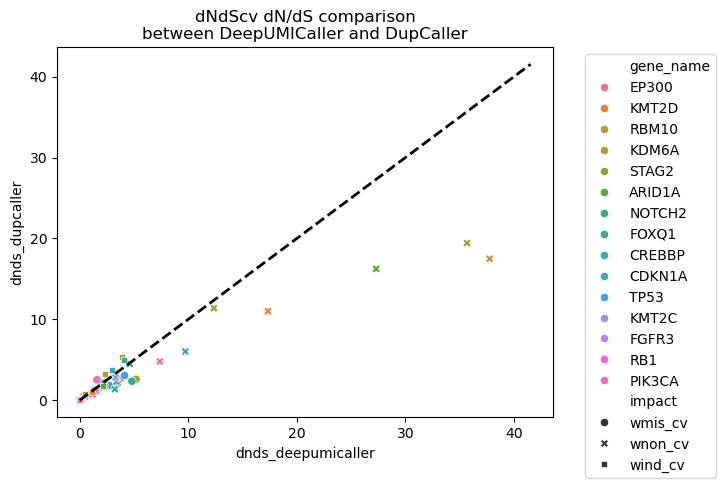

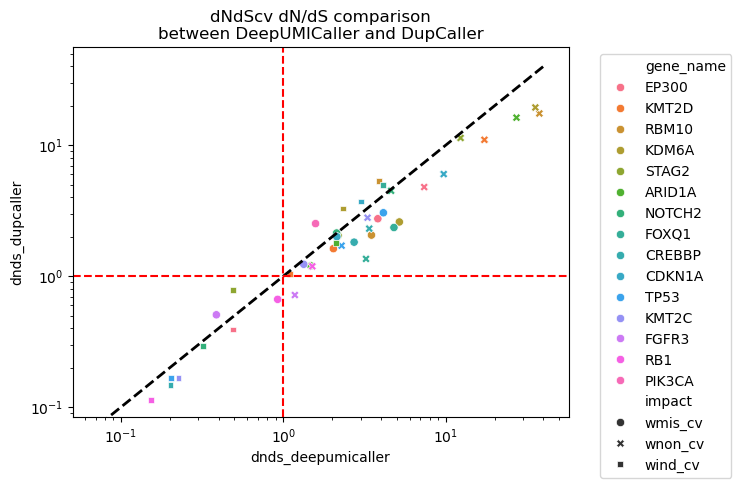

In [9]:
sns.scatterplot(data=reduced_omegas, x="dnds_deepumicaller", y="dnds_dupcaller",
            hue = 'gene_name',
            style = "impact",
            # kind="box",
            # height=4, aspect=1.5
            )
max_dnds = max(reduced_omegas["dnds_deepumicaller"].max(), reduced_omegas["dnds_dupcaller"].max()) * 1.1

# add x = y line
plt.plot([0, max_dnds], [0, max_dnds], 'k--', lw=2)
# plt.xscale('log')
# plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("dNdScv dN/dS comparison\nbetween DeepUMICaller and DupCaller")
plt.show()


sns.scatterplot(data=reduced_omegas, x="dnds_deepumicaller", y="dnds_dupcaller",
            hue = 'gene_name',
            style = "impact",
            # kind="box",
            # height=4, aspect=1.5
            )
max_dnds = max(reduced_omegas["dnds_deepumicaller"].max(), reduced_omegas["dnds_dupcaller"].max()) * 1.1

# add x = y line
plt.plot([0, max_dnds], [0, max_dnds], 'k--', lw=2)
plt.axvline(x=1, color='r', linestyle='--')
plt.axhline(y=1, color='r', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("dNdScv dN/dS comparison\nbetween DeepUMICaller and DupCaller")
plt.show()

In [10]:
reduced_omegas = reduced_omegas[(reduced_omegas["impact"] == 'wind_cv')]

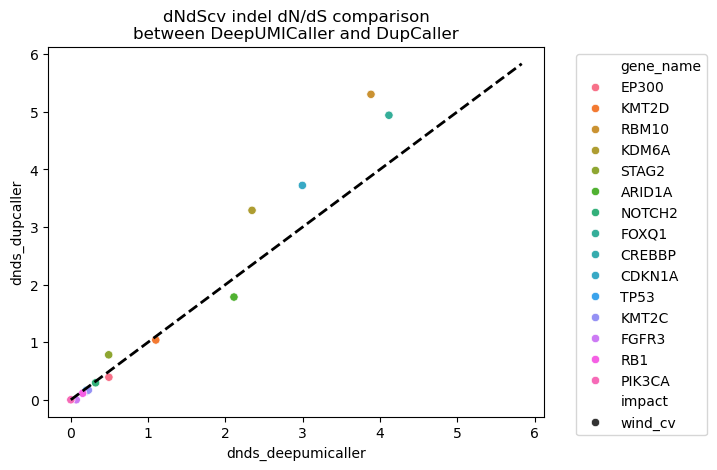

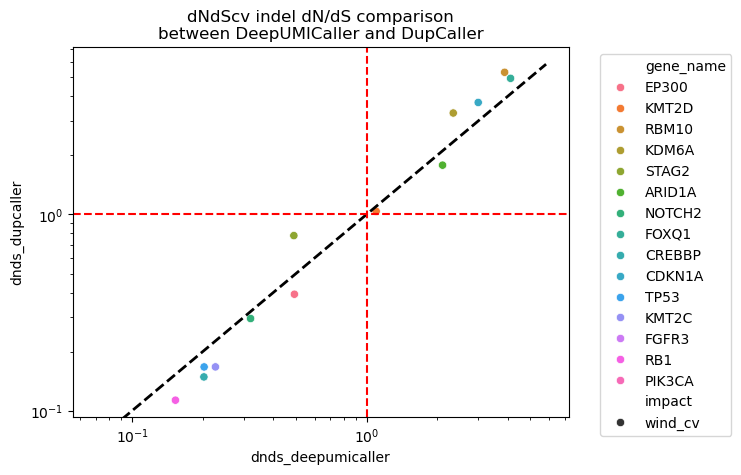

In [11]:
sns.scatterplot(data=reduced_omegas, x="dnds_deepumicaller", y="dnds_dupcaller",
            hue = 'gene_name',
            style = "impact",
            # kind="box",
            # height=4, aspect=1.5
            )
max_dnds = max(reduced_omegas["dnds_deepumicaller"].max(), reduced_omegas["dnds_dupcaller"].max()) * 1.1

# add x = y line
plt.plot([0, max_dnds], [0, max_dnds], 'k--', lw=2)
# plt.xscale('log')
# plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("dNdScv indel dN/dS comparison\nbetween DeepUMICaller and DupCaller")
plt.show()


sns.scatterplot(data=reduced_omegas, x="dnds_deepumicaller", y="dnds_dupcaller",
            hue = 'gene_name',
            style = "impact",
            # kind="box",
            # height=4, aspect=1.5
            )
max_dnds = max(reduced_omegas["dnds_deepumicaller"].max(), reduced_omegas["dnds_dupcaller"].max()) * 1.1

# add x = y line
plt.plot([0, max_dnds], [0, max_dnds], 'k--', lw=2)
plt.axvline(x=1, color='r', linestyle='--')
plt.axhline(y=1, color='r', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("dNdScv indel dN/dS comparison\nbetween DeepUMICaller and DupCaller")
plt.show()

## Domain level

In [26]:
# omegas = pd.read_table("../data/bladder/omega.flagged_annotated.tsv")
# omegas = pd.read_table(f"{deepcsa_run_dir}/selection/omegagloballoc/all_omega_globalloc.tsv")
omegas = pd.read_table(f"{deepcsa_run_dir}/selection/omega/omega.flagged_annotated.tsv")
omegas.head()

,gene,sample,impact,mutations,dnds,pvalue,lower,upper,pvalue_adj,flagged,flag_reason
0,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0051_BDO_01_dupcaller,missense,1,0.332614,0.179826,0.019452,1.471530,0.340571,False,NaN
1,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0051_BDO_01_dupcaller,nonsense,4,8.495313,0.001706,2.575170,20.654126,0.007787,False,NaN
2,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0051_BDO_01_dupcaller,truncating,4,8.495313,0.001706,2.575170,20.654126,0.007787,False,NaN
3,ARID1A--exon_7_ENST00000324856_ENSE00001349760,P19_0051_BDO_01_dupcaller,nonsynonymous_splice,5,1.432809,0.450743,0.511596,3.105783,0.581779,False,NaN
4,KMT2D--PHD/RING_ZnF,P19_0051_BDO_01_dupcaller,missense,2,0.861719,0.829799,0.143081,2.684229,0.884412,False,NaN


In [27]:
omegas = omegas[~(omegas["gene"].str.contains("--exon"))
                & (omegas["gene"].str.contains("--"))
                ]

In [30]:
reduced_omegas = omegas[(omegas["gene"].str.contains("RBM10"))
                          & (omegas["sample"].isin(['CallerDeepumicaller', 'CallerDupcaller']))
                          & (omegas["impact"].isin(['missense']))
                          ]
reduced_omegas.sort_values(by=["gene", "sample", "impact"])

,gene,sample,impact,mutations,dnds,pvalue,lower,upper,pvalue_adj,flagged,flag_reason
2744,RBM10--G-patch,CallerDupcaller,missense,6,2.746875,3.522998e-02,1.083769,5.630786,6.687866e-02,False,NaN
4310,RBM10--RBM10_OCRE,CallerDeepumicaller,missense,10,3.590601,9.116530e-04,1.788062,6.365869,2.277006e-03,False,NaN
2715,RBM10--RBM10_OCRE,CallerDupcaller,missense,20,3.795313,1.370907e-06,2.344399,5.783838,4.644887e-06,False,NaN
3062,RBM10--RBM10_RRM_2,CallerDupcaller,missense,69,22.975000,1.170000e-38,17.680183,29.371484,4.697550e-38,False,NaN
2120,RBM10--RRM_domain,CallerDupcaller,missense,4,0.262085,7.343888e-04,0.081884,0.613647,1.863236e-03,False,NaN
4288,RBM10--RanBP2_ZnF,CallerDeepumicaller,missense,2,0.757373,6.821539e-01,0.126047,2.357715,7.427385e-01,False,NaN
2686,RBM10--RanBP2_ZnF,CallerDupcaller,missense,3,1.259277,7.023026e-01,0.311949,3.290527,7.610648e-01,False,NaN
4109,RBM10--ZnF_C2H2_type,CallerDeepumicaller,missense,33,5.431226,1.170000e-38,3.728490,7.632764,4.697550e-38,False,NaN
2388,RBM10--ZnF_C2H2_type,CallerDupcaller,missense,51,6.721863,1.170000e-38,4.960327,8.913635,4.697550e-38,False,NaN


In [14]:
# # horizontal barplot
# import matplotlib.pyplot as plt
# import seaborn as sns
# import matplotlib.patches as mpatches


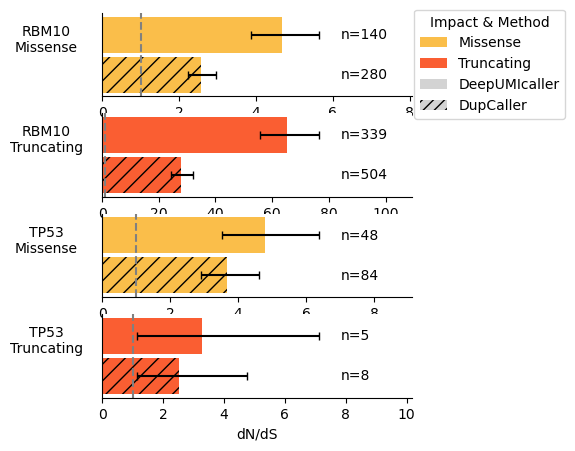

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import matplotlib.patches as mpatches

# # Create figure with 4 subplots: 2 for RBM10 and 2 for TP53 (missense and truncating separately for both)
# fig, (ax_rbm_mis, ax_rbm_tru, ax_tp53_mis, ax_tp53_tru) = plt.subplots(4, 1, figsize=(4, 5), height_ratios=[1, 1, 1, 1])

# # Define common parameters
# palette = {"truncating": "#FA5E32", "missense": "#FABE4A"}


# # Helper function to style bars
# def style_gene_segments(ax, data, label, impact_filter=None):
#     # Filter data if impact_filter is provided
#     plot_data = data.copy()
#     if impact_filter:
#         plot_data = plot_data[plot_data['impact'] == impact_filter]
    
#     # Standardize data order
#     plot_data = plot_data.sort_values(['impact', 'sample'])
    
#     if plot_data.empty:
#         return

#     # Use gap to separate impact groups and width to make bars thinner
#     sns.barplot(
#         y="impact", x="dnds", data=plot_data,
#         hue="sample", palette={"CallerDeepumicaller": "#cccccc", "CallerDupcaller": "#cccccc"},
#         ax=ax, gap=0.1, width=0.6
#     )
    
#     # Determine the maximum x value to align text
#     max_x = max(plot_data['upper'].fillna(plot_data['dnds']).max(), plot_data['dnds'].max())
#     text_x_pos = max_x * 1.1 # Add padding relative to scale
    
#     num_hues = len(plot_data['sample'].unique())
#     num_categories = len(plot_data['impact'].unique())
#     bars = ax.patches
    
#     # We iterate and assign attributes based on data indices
#     for hue_idx in range(num_hues):
#         sample_names = plot_data['sample'].unique()
#         if hue_idx >= len(sample_names): continue
#         sample_name = sample_names[hue_idx]
#         for cat_idx in range(num_categories):
#             impact_names = plot_data['impact'].unique()
#             if cat_idx >= len(impact_names): continue
#             impact_name = impact_names[cat_idx]
            
#             # Find the actual bar patch
#             bar_idx = hue_idx * num_categories + cat_idx
#             if bar_idx >= len(bars): continue
#             bar = bars[bar_idx]
            
#             # Apply Style
#             bar.set_facecolor(palette[impact_name])
#             if "Dupcaller" in sample_name:
#                 bar.set_hatch('//')
            
#             # Mutation Count Text
#             row = plot_data[(plot_data['impact'] == impact_name) & (plot_data['sample'] == sample_name)]
#             if not row.empty:
#                 count = row['mutations'].values[0]
#                 lower = row['lower'].values[0]
#                 upper = row['upper'].values[0]
#                 dnds = row['dnds'].values[0]
                
#                 # Add Error Bars (Confidence Intervals)
#                 if not (pd.isna(lower) or pd.isna(upper)):
#                     # Handle symmetric vs asymmetric error bars correctly
#                     xerr = [[max(0, dnds - lower)], [max(0, upper - dnds)]]
#                     ax.errorbar(dnds, bar.get_y() + bar.get_height()/2, xerr=xerr, 
#                                 fmt='none', ecolor='black', capsize=3)

#                 # Mutation Count Text (aligned to the right)
#                 ax.text(text_x_pos, bar.get_y() + bar.get_height()/2, f'n={count}', 
#                          va='center', ha='left', fontsize=10)

#     ax.axvline(x=1, color='grey', linestyle='--')
#     ax.set_ylabel(label, rotation = 0, labelpad=40)
#     ax.set_xlabel('dN/dS')
#     ax.set_yticks([])
#     # Adjust x-limits to accommodate the right-aligned text
#     ax.set_xlim(right=text_x_pos * 1.3)
#     if ax.get_legend(): ax.get_legend().remove()

# # Execute for RBM10 separated into two axes
# rbm10_data = reduced_omegas[reduced_omegas["gene"] == "RBM10"]
# style_gene_segments(ax_rbm_mis, rbm10_data, "RBM10\nMissense", impact_filter="missense")
# style_gene_segments(ax_rbm_tru, rbm10_data, "RBM10\nTruncating", impact_filter="truncating")

# # Execute for TP53 separated into two axes
# tp53_data = reduced_omegas[reduced_omegas["gene"] == "TP53"]
# style_gene_segments(ax_tp53_mis, tp53_data, "TP53\nMissense", impact_filter="missense")
# style_gene_segments(ax_tp53_tru, tp53_data, "TP53\nTruncating", impact_filter="truncating")

# # Common Legend
# legend_elements = [
#     mpatches.Patch(facecolor=palette["missense"], label='Missense'),
#     mpatches.Patch(facecolor=palette["truncating"], label='Truncating'),
#     mpatches.Patch(facecolor='lightgray', label='DeepUMIcaller'),
#     mpatches.Patch(facecolor='lightgray', hatch='///', label='DupCaller')
# ]
# fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 0.9), title="Impact & Method")

# sns.despine()

# # plt.tight_layout()
# plt.savefig("../plots/bladder/dnds/TP53_RBM10_all_separate_axes.pdf", bbox_inches='tight')
# plt.show()

In [ ]:
# print(reduced_omegas.to_csv(sep="\t", index=False))

gene	sample	impact	mutations	dnds	pvalue	lower	upper	pvalue_adj	flagged	flag_reason
TP53	CallerDupcaller	missense	84	3.6749877929687553	1.17e-38	2.895641023516659	4.604553222656255	1.8524999999999998e-38	False	
TP53	CallerDupcaller	truncating	8	2.521875000000003	0.024868846	1.1408343505859389	4.767358398437503	0.0312402032396694	False	
RBM10	CallerDupcaller	missense	280	2.573437500000004	1.17e-38	2.2235933685302767	2.970166015625004	1.8524999999999998e-38	False	
RBM10	CallerDupcaller	truncating	504	27.86250000000005	1.17e-38	24.20243942260747	32.061108398437554	1.8524999999999998e-38	False	
TP53	CallerDeepumicaller	missense	48	4.793750000000008	1.17e-38	3.513723144531256	6.378222656250008	1.8524999999999998e-38	False	
TP53	CallerDeepumicaller	truncating	5	3.2656250000000044	0.027890444	1.1617091369628922	7.121826171875004	0.0347487499016393	False	
RBM10	CallerDeepumicaller	missense	140	4.6937500000000085	1.17e-38	3.8727215576171945	5.6410156250000085	1.8524999999999998e-38	False	
RBM10

In [ ]:
#  selection/dndscv/cv/all_dNdScv.cv.tsv